
# Named Entity Recognition with Conditional Random Fields

*A lecture note on going from "predict one tag from local context" to
"predict the whole tag sequence jointly, from arbitrary features of the
whole sentence."*

---

## 1. Intro: finding the "who, where, and what organization" in raw text

Imagine you're building a system that reads news articles and automatically
pulls out a structured list: *which people are mentioned, which
organizations, which places*. A human reading the sentence

> "Boris Becker, who was born in Leimen, played for Germany at Wimbledon."

instantly knows `Boris Becker` is a person, `Leimen` and `Germany` are
places, and `Wimbledon` is... also a place (a tennis venue), all without
being told any rules in advance. Teaching a computer to do this — **Named
Entity Recognition (NER)** — means teaching it to read a sentence
word-by-word and label each word: is this word part of a person's name? An
organization? A location? Or none of the above?

This is harder than it sounds. The same word can be a name in one sentence
and an ordinary word in another ("Jordan" the person vs. "Jordan" the
country vs. "jordan" almonds). The same entity can span multiple words
("New York City" is *one* place, not three). And the clues that tell you
"this is a name" are scattered all over the sentence — capitalization, the
word before it ("Mr.", "President"), the word after it, what part of
speech it is, whether it looks like an abbreviation.

By the end of this tutorial you'll be able to:

- Explain **BIO tagging**, the standard scheme for turning "find the
  entities" into a per-word labeling problem.
- State precisely what a **linear-chain Conditional Random Field (CRF)**
  is, and why it's a strictly more expressive alternative to the Hidden
  Markov Model (HMM) you'd use for a task like part-of-speech tagging.
- Hand-engineer a real per-token feature set and train a real CRF on the
  real CoNLL-2003 dataset, using `sklearn-crfsuite` — the standard
  practitioner library for this exact task.
- Read the model's learned feature weights to see *what it actually
  learned*, and honestly evaluate where it succeeds and fails.

**This tutorial is the direct successor to this domain's HMM-based
part-of-speech tagging tutorial.** Both are *sequence labeling* problems:
walk through a sentence, assign one label per word. The difference is
entirely in *how much of the sentence each label is allowed to look at*
when it's assigned — and that difference is the whole story of this
tutorial.



## 2. The idea, intuitively

### 2.1 From "one tag per word" to "find the entity spans"

Let's start with the simplest possible idea: give every word one of a
small set of tags — `PER` (person), `ORG` (organization), `LOC`
(location), `MISC` (miscellaneous entity), or `O` (not an entity at all).

Take the sentence:

> "Mark Watney works at NASA in Houston."

A first attempt might tag it:

| Mark | Watney | works | at | NASA | in | Houston | . |
|---|---|---|---|---|---|---|---|
| PER | PER | O | O | ORG | O | LOC | O |

That looks fine here — but consider a sentence with **two separate
one-word entities sitting right next to each other**:

> "... commissioner Bud Selig fined the Yankees and Mets ..."

If `Yankees` and `Mets` are tagged `ORG ORG`, how do you know that's *two*
different organizations next to each other, and not *one* two-word
organization (imagine instead the tokens were "New York Mets" — now you'd
want two `ORG` tags in a row to mean "one entity, two words")? Plain
per-word type tags like `PER`/`ORG`/`LOC`/`O` **cannot distinguish "two
separate one-word entities in a row" from "one multi-word entity."** The
tag sequence looks identical either way.

### 2.2 The fix: BIO tagging

**BIO tagging** fixes this by tagging not just *what kind* of entity a
word belongs to, but *where in the entity* it sits:

- **`B-X`** — this word **B**egins a new entity of type `X`.
- **`I-X`** — this word continues (is **I**nside) an entity of type `X`
  that started on a previous word.
- **`O`** — this word is **O**utside any entity.

Now the two cases above are distinguishable:

| | one multi-word ORG | two one-word ORGs |
|---|---|---|
| New / Yankees | `B-ORG` | `B-ORG` |
| York / and | `I-ORG` | `O` |
| Mets | `I-ORG` | `B-ORG` |

Every time you see a `B-ORG` immediately after another `ORG` tag, you know
a *new* entity has started, even though both entities are the same type
and sit back-to-back. This is exactly the ambiguity plain type-only tags
couldn't resolve. Let's see it on a real, tiny example before anything
else.


In [1]:

# A tiny, hand-labeled example to make BIO concrete before we touch real data / models.

tokens   = ["Yankees", "and", "Mets", "fans", "packed", "New", "York", "City", "."]
bio_tags = ["B-ORG",   "O",   "B-ORG","O",    "O",      "B-LOC","I-LOC","I-LOC","O"]

for tok, tag in zip(tokens, bio_tags):
    print(f"{tok:>10}  {tag}")


   Yankees  B-ORG
       and  O
      Mets  B-ORG
      fans  O
    packed  O
       New  B-LOC
      York  I-LOC
      City  I-LOC
         .  O



Notice: `Yankees` and `Mets` are two *separate* `B-ORG` tags (two
one-word organizations, only "and" separating them), while `New York City`
is a single three-word entity: one `B-LOC` followed by two `I-LOC` tags.
The tag sequence alone now fully recovers the entity boundaries — that's
the whole point of BIO.

> **Takeaway:** BIO turns "find spans of entities" into "assign one of a
> larger, position-aware tag set to each word" — a problem we can throw
> standard sequence-labeling machinery at. With 4 entity types (PER, ORG,
> LOC, MISC) plus O, that's `4*2 + 1 = 9` possible tags per word — exactly
> what we'll see in the real CoNLL-2003 label set below.

### 2.3 Why not just reuse the HMM from POS tagging?

The previous tutorial in this domain used a **Hidden Markov Model (HMM)**
for POS tagging. An HMM is tempting to reuse here — it's also a
sequence-tagging model — but it has a structural limitation that matters a
lot for NER specifically.

An HMM is **generative**: it models how the *whole* sentence together with
its tags was supposedly "generated," via two small local pieces:

- a transition probability $P(\text{tag}_i \mid \text{tag}_{i-1})$, and
- an emission probability $P(\text{word}_i \mid \text{tag}_i)$.

The emission probability is the bottleneck: it can only look at **the
current word**, conditioned on **the current tag**, in isolation. It has
no principled way to also use "is the *previous* word `Mr.`?" or "is the
*next* word capitalized?" or "what's this word's suffix?" as evidence,
because emission probabilities are indexed by a single word and a single
tag — adding more signals means jointly modeling the probability of
generating all of those signals too, which breaks the clean, tractable
math an HMM relies on.

For POS tagging this limitation is bearable — a word's part of speech is
mostly determined by the word itself. For NER it's a real problem: whether
"Washington" is a `PER` or a `LOC` depends heavily on context around it
("George Washington" vs. "Washington D.C." vs. "traveled to Washington"),
and an HMM's emission model structurally can't use that context as a
feature. We need a model that can look at **arbitrary features of the
whole observed sentence** when scoring each tag — that's exactly what a
**Conditional Random Field** gives us, and it's the subject of the rest of
this tutorial.



## 3. Going deeper: the formal definition

### 3.1 Generative vs. discriminative, precisely

An HMM models the **joint** distribution of words and tags,
$P(\mathbf{x}, \mathbf{y})$, and factors it into local pieces via Bayes'
rule and a strong independence assumption (each tag depends only on the
previous tag; each word depends only on its own tag). To *use* it for
tagging, you flip it around with Bayes' rule to get $P(\mathbf{y} \mid
\mathbf{x})$.

A **linear-chain Conditional Random Field (CRF)** skips the detour: it
models $P(\mathbf{y} \mid \mathbf{x})$ **directly**, and is called
**discriminative** for exactly that reason — it only ever tries to
discriminate between candidate tag sequences $\mathbf{y}$ given the
observed sentence $\mathbf{x}$; it never bothers modeling how $\mathbf{x}$
itself was generated. This single change is what unlocks arbitrary
features, as we'll see below.

### 3.2 The CRF scoring function

Let $\mathbf{x} = (x_1, \ldots, x_n)$ be the observed sentence (all $n$
words, and — crucially — anything you can compute from them: capitalization,
suffixes, POS tags, neighboring words, etc.) and $\mathbf{y} = (y_1,
\ldots, y_n)$ be a candidate BIO tag sequence of the same length. A
linear-chain CRF defines:

$$
P(\mathbf{y} \mid \mathbf{x}) = \frac{1}{Z(\mathbf{x})} \exp\left( \sum_{k} \lambda_k \sum_{i=1}^{n} f_k(y_{i-1}, y_i, \mathbf{x}, i) \right)
$$

Every symbol, defined:

- $f_k(y_{i-1}, y_i, \mathbf{x}, i)$ — a **feature function**. Each one
  looks at the tag at the current position $y_i$, the tag at the previous
  position $y_{i-1}$, the *entire* observed sentence $\mathbf{x}$, and the
  current position $i$, and returns a number (often just $0$ or $1$ — "is
  this pattern present here?"). Example: $f_k(y_{i-1}, y_i, \mathbf{x}, i)
  = 1$ if $y_i = \text{B-PER}$ and word $x_i$ is capitalized, else $0$.
- $\lambda_k$ — the **learned weight** for feature $f_k$. A large positive
  $\lambda_k$ means "when this feature fires, it's strong evidence for
  this tagging"; a large negative weight means the opposite. These are the
  parameters training actually learns (via gradient-based optimization of
  the log-likelihood — `sklearn-crfsuite` uses L-BFGS under the hood).
- $\sum_{i=1}^n f_k(\cdot)$ — each feature is evaluated (and its weighted
  vote counted) **at every position** in the sentence, then summed. A
  feature like "previous tag was `B-PER` and current word is capitalized"
  can fire many times across a long sentence.
- $Z(\mathbf{x}) = \sum_{\mathbf{y}'} \exp\left( \sum_k \lambda_k \sum_i
  f_k(y'_{i-1}, y'_i, \mathbf{x}, i) \right)$ — the **partition function**.
  It sums the (unnormalized) score of *every possible tag sequence*
  $\mathbf{y}'$ of length $n$, so that dividing by it turns raw scores into
  a valid probability distribution over tag sequences that sums to 1. This
  sum is over exponentially many sequences ($9^n$ for our 9-tag scheme) but
  is computed tractably with a dynamic-programming forward-backward
  algorithm, exactly analogous to the HMM's forward algorithm.

Read as a whole: **a CRF scores an entire candidate tag sequence by summing
up weighted "evidence votes" from feature functions evaluated at every
position, then converts that global score into a probability by
normalizing over all competing sequences.** This is a genuinely different
computation from an HMM multiplying together a chain of small local
probabilities — it's *one global, undirected scoring function* over the
whole sequence, not a product of independent local generative steps
(that's also why it's called a *random field* rather than a *chain* of
distributions — the graph of dependencies is undirected).

### 3.3 Why this unlocks arbitrary, overlapping features

Because $f_k$ takes the *entire* $\mathbf{x}$ and position $i$ as
arguments — not just "the word at position $i$" — a feature function is
free to look anywhere in the sentence relative to $i$:

- "Is $x_i$ capitalized?"
- "Is $x_{i-1}$ (the previous word) one of `Mr.`, `Dr.`, `President`?"
- "What are the last 3 characters of $x_i$?" (captures suffixes like
  `-son`, `-burg`, `-ville`)
- "Is $x_{i+1}$ (the next word) also capitalized?"
- "What part of speech is $x_i$?"

None of these has to be mutually exclusive with any other — they can
**overlap freely**, and the model just learns a weight for each. An HMM's
emission probability $P(x_i \mid y_i)$ is a single conditional
distribution over one word given one tag; there is no slot in that formula
for "and also look at the previous word." A CRF has no such restriction
because feature functions are just arbitrary functions of the whole input
— this is the concrete mechanism behind the discriminative/generative
distinction in §3.1, and it's exactly what we'll exploit when we
hand-engineer features below.

> **Takeaway:** the partition function $Z(\mathbf{x})$ is what makes a CRF
> a valid probability model despite scoring globally; the feature
> functions $f_k$ are what make it able to use arbitrary, overlapping
> signals an HMM structurally cannot.



## 4. Visuals: what a "feature window" actually looks like

Before touching real data, let's visualize the core intuition from §3.3:
at each position, a CRF's feature functions can see a whole window around
the current word, not just the word itself. The plot below shows, for one
example sentence, which positions contribute features to the tagging
decision at word index 4 (`NASA`).


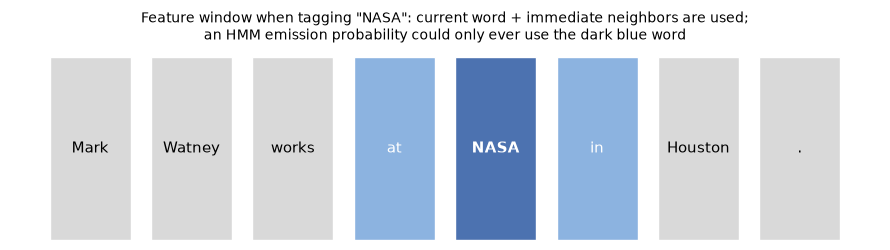

In [2]:

import matplotlib.pyplot as plt
import numpy as np

sentence = ["Mark", "Watney", "works", "at", "NASA", "in", "Houston", "."]
center = 4  # index of "NASA"

fig, ax = plt.subplots(figsize=(9, 2.6))

colors = []
for i in range(len(sentence)):
    if i == center:
        colors.append("#4C72B0")       # current word: strong
    elif abs(i - center) == 1:
        colors.append("#8CB3E0")       # immediate neighbor: used by CRF features
    else:
        colors.append("#D9D9D9")       # out of window: an HMM emission also can't see this,
                                        # and our hand-crafted CRF features don't reach this far either

ax.bar(range(len(sentence)), [1] * len(sentence), color=colors, edgecolor="white")
for i, tok in enumerate(sentence):
    ax.text(i, 0.5, tok, ha="center", va="center", fontsize=11,
             color="white" if i == center or abs(i - center) == 1 else "black",
             fontweight="bold" if i == center else "normal")

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title('Feature window when tagging "NASA": current word + immediate neighbors are used;\n'
             "an HMM emission probability could only ever use the dark blue word", fontsize=10)
plt.tight_layout()
plt.savefig("feature_window.png", dpi=110)
plt.show()



The dark word is what an HMM's emission probability is limited to. The
lighter neighbors are context a CRF's feature functions can pull in (in
our implementation below, we'll use a window of one word on either side —
you could extend it further, at the cost of more parameters to learn).
Now let's build this for real, on real data.



## 5. Implementation

### 5.1 Loading the real dataset: CoNLL-2003

We use the canonical **CoNLL-2003** English NER dataset (Sang & De
Meulder, 2003) via Hugging Face `datasets`. It consists of Reuters news
text manually annotated with four entity types — **PER** (person),
**ORG** (organization), **LOC** (location), **MISC** (miscellaneous, e.g.
nationalities, events) — in BIO format, split into train / validation /
test.


In [3]:

from datasets import load_dataset

raw = load_dataset("tomaarsen/conll2003")
print(raw)

label_names = raw["train"].features["ner_tags"].feature.names
print("\nLabel set:", label_names)


DatasetDict({
    train: Dataset({
        features: ['id', 'document_id', 'sentence_id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'document_id', 'sentence_id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'document_id', 'sentence_id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})

Label set: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']


In [4]:

# Look at one real example end to end.
example = raw["train"][0]
print("tokens:  ", example["tokens"])
print("ner_tags:", [label_names[t] for t in example["ner_tags"]])


tokens:   ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']
ner_tags: ['B-ORG', 'O', 'B-MISC', 'O', 'O', 'O', 'B-MISC', 'O', 'O']



### 5.2 Hand-engineering features

This is the pedagogically important step this tutorial is built around:
**a CRF is only as good as the features you hand it.** For each token we
compute a dictionary of named features — the word itself, shape features
(capitalization, digits), prefix/suffix substrings, its part-of-speech
tag, and the same set of features for the previous and next token, so the
model gets local context exactly like the window we visualized above.


In [5]:

import nltk

def pos_tags_for(tokens):
    # POS-tag a whole sentence at once so nltk's tagger has real context.
    return [tag for _, tag in nltk.pos_tag(tokens)]


def word_features(tokens, pos_tags, i):
    word = tokens[i]
    postag = pos_tags[i]

    feats = {
        "bias": 1.0,
        "word.lower()": word.lower(),
        "word.isupper()": word.isupper(),
        "word.istitle()": word.istitle(),
        "word.isdigit()": word.isdigit(),
        "word[-3:]": word[-3:],
        "word[-2:]": word[-2:],
        "word[:2]": word[:2],
        "postag": postag,
    }

    if i > 0:
        prev_word = tokens[i - 1]
        prev_pos = pos_tags[i - 1]
        feats.update({
            "-1:word.lower()": prev_word.lower(),
            "-1:word.istitle()": prev_word.istitle(),
            "-1:word.isupper()": prev_word.isupper(),
            "-1:postag": prev_pos,
        })
    else:
        feats["BOS"] = True  # beginning of sentence

    if i < len(tokens) - 1:
        next_word = tokens[i + 1]
        next_pos = pos_tags[i + 1]
        feats.update({
            "+1:word.lower()": next_word.lower(),
            "+1:word.istitle()": next_word.istitle(),
            "+1:word.isupper()": next_word.isupper(),
            "+1:postag": next_pos,
        })
    else:
        feats["EOS"] = True  # end of sentence

    return feats


def sentence_to_features(tokens):
    pos_tags = pos_tags_for(tokens)
    return [word_features(tokens, pos_tags, i) for i in range(len(tokens))]


# Sanity check on the example above: show the feature dict for one token.
demo_tokens = example["tokens"]
demo_feats = sentence_to_features(demo_tokens)
print("Token: ", demo_tokens[4])
for k, v in demo_feats[4].items():
    print(f"  {k:>20}: {v}")


Token:  to
                  bias: 1.0
          word.lower(): to
        word.isupper(): False
        word.istitle(): False
        word.isdigit(): False
             word[-3:]: to
             word[-2:]: to
              word[:2]: to
                postag: TO
       -1:word.lower(): call
     -1:word.istitle(): False
     -1:word.isupper(): False
             -1:postag: NN
       +1:word.lower(): boycott
     +1:word.istitle(): False
     +1:word.isupper(): False
             +1:postag: VB



### 5.3 Building train/test sets and training the CRF

We use a few thousand sentences from the real train split (enough to learn
solid feature weights, small enough to train in well under a minute) and
evaluate on the **entire real test split** so the reported numbers are
directly comparable to published CoNLL-2003 results.


In [6]:

import random

random.seed(0)

N_TRAIN_SENTENCES = 4000  # a few thousand sentences, as planned

train_split = raw["train"]
test_split = raw["test"]

train_idx = list(range(len(train_split)))
random.shuffle(train_idx)
train_idx = train_idx[:N_TRAIN_SENTENCES]

def build_xy(split, indices=None):
    X, Y = [], []
    idx_iter = indices if indices is not None else range(len(split))
    for i in idx_iter:
        row = split[i]
        tokens = row["tokens"]
        if len(tokens) == 0:
            continue
        tags = [label_names[t] for t in row["ner_tags"]]
        X.append(sentence_to_features(tokens))
        Y.append(tags)
    return X, Y

X_train, y_train = build_xy(train_split, train_idx)
X_test, y_test = build_xy(test_split)

print(f"Training sentences: {len(X_train)}")
print(f"Test sentences:     {len(X_test)}")


Training sentences: 4000
Test sentences:     3453


In [7]:

import sklearn_crfsuite

crf = sklearn_crfsuite.CRF(
    algorithm="lbfgs",
    c1=0.1,   # L1 regularization strength
    c2=0.1,   # L2 regularization strength
    max_iterations=100,
    all_possible_transitions=True,
)
crf.fit(X_train, y_train)
print("Training complete.")
print("Number of learned transition features + state features:",
      len(crf.transition_features_) + len(crf.state_features_))


Training complete.


Number of learned transition features + state features: 14130



### 5.4 Evaluation: token-level precision, recall, F1 per entity type

We report real `sklearn_crfsuite.metrics.flat_classification_report`
numbers on the held-out CoNLL-2003 test set — the same split used in the
original shared task, so these numbers are directly interpretable against
published CRF/CoNLL-2003 results. We exclude the (dominant, uninteresting)
`O` tag from the *summary* metrics so the per-entity numbers aren't
washed out, but keep it in the underlying evaluation so boundary errors
are still counted correctly.


In [8]:

from sklearn_crfsuite import metrics as crf_metrics

y_pred = crf.predict(X_test)

labels = list(crf.classes_)
labels_no_o = [l for l in labels if l != "O"]
# sort so B-X / I-X pairs of the same type sit together, easier to read
sorted_labels = sorted(labels_no_o, key=lambda name: (name[2:], name[0]))

report = crf_metrics.flat_classification_report(
    y_test, y_pred, labels=sorted_labels, digits=3
)
print(report)


              precision    recall  f1-score   support

       B-LOC      0.827     0.803     0.814      1668
       I-LOC      0.724     0.611     0.662       257
      B-MISC      0.762     0.702     0.731       702
      I-MISC      0.558     0.583     0.570       216
       B-ORG      0.729     0.672     0.699      1661
       I-ORG      0.636     0.687     0.661       835
       B-PER      0.786     0.832     0.808      1617
       I-PER      0.849     0.924     0.885      1156

   micro avg      0.767     0.767     0.767      8112
   macro avg      0.734     0.727     0.729      8112
weighted avg      0.766     0.767     0.765      8112



In [9]:

overall_f1 = crf_metrics.flat_f1_score(y_test, y_pred, average="weighted", labels=labels_no_o)
print(f"Overall weighted F1 (entity tags only, excluding O): {overall_f1:.3f}")


Overall weighted F1 (entity tags only, excluding O): 0.765



### 5.5 Entity-level (span) evaluation

Token-level F1 can look better than it should, because most tokens in most
sentences are `O` and easy to get right, and a single wrong tag inside a
correct span still partially "counts" at the token level. A stricter and
more realistic view for real NER pipelines is **entity-level F1**: an
entity is only counted correct if its *entire span and type* are matched
exactly (e.g. predicting `B-LOC I-LOC` for a true `B-LOC I-LOC I-LOC` span
of "New York City" is a miss, not a partial credit).


In [10]:

def bio_to_spans(tags):
    # Convert a BIO tag sequence into a set of (start, end, type) entity spans.
    spans = []
    start, ent_type = None, None
    for i, tag in enumerate(tags + ["O"]):  # sentinel to flush a trailing entity
        if tag.startswith("B-"):
            if start is not None:
                spans.append((start, i, ent_type))
            start, ent_type = i, tag[2:]
        elif tag.startswith("I-") and ent_type == tag[2:]:
            continue
        else:
            if start is not None:
                spans.append((start, i, ent_type))
            start, ent_type = None, None
    return spans


def entity_level_prf(y_true, y_pred):
    from collections import Counter
    tp, fp, fn = Counter(), Counter(), Counter()
    for true_tags, pred_tags in zip(y_true, y_pred):
        true_spans = set(bio_to_spans(true_tags))
        pred_spans = set(bio_to_spans(pred_tags))
        for span in pred_spans:
            (tp if span in true_spans else fp)[span[2]] += 1
        for span in true_spans:
            if span not in pred_spans:
                fn[span[2]] += 1

    rows = {}
    ent_types = sorted(set(list(tp) + list(fp) + list(fn)))
    for et in ent_types:
        p = tp[et] / (tp[et] + fp[et]) if (tp[et] + fp[et]) else 0.0
        r = tp[et] / (tp[et] + fn[et]) if (tp[et] + fn[et]) else 0.0
        f1 = 2 * p * r / (p + r) if (p + r) else 0.0
        rows[et] = {"precision": p, "recall": r, "f1": f1,
                    "support": tp[et] + fn[et]}
    return rows


entity_scores = entity_level_prf(y_test, y_pred)
for et, sc in entity_scores.items():
    print(f"{et:>5}  P={sc['precision']:.3f}  R={sc['recall']:.3f}  "
          f"F1={sc['f1']:.3f}  support={sc['support']}")


  LOC  P=0.820  R=0.797  F1=0.808  support=1668
 MISC  P=0.730  R=0.672  F1=0.700  support=702
  ORG  P=0.685  R=0.631  F1=0.657  support=1661
  PER  P=0.780  R=0.826  F1=0.802  support=1617



### 5.6 Interpretability: which features did the model actually learn to rely on?

`sklearn-crfsuite` exposes every learned state feature weight $\lambda_k$
(§3.2). We can pull out, per entity type, the top hand-crafted features
the model leans on most heavily — this is a direct, honest look at what
the CRF learned, not a guess.


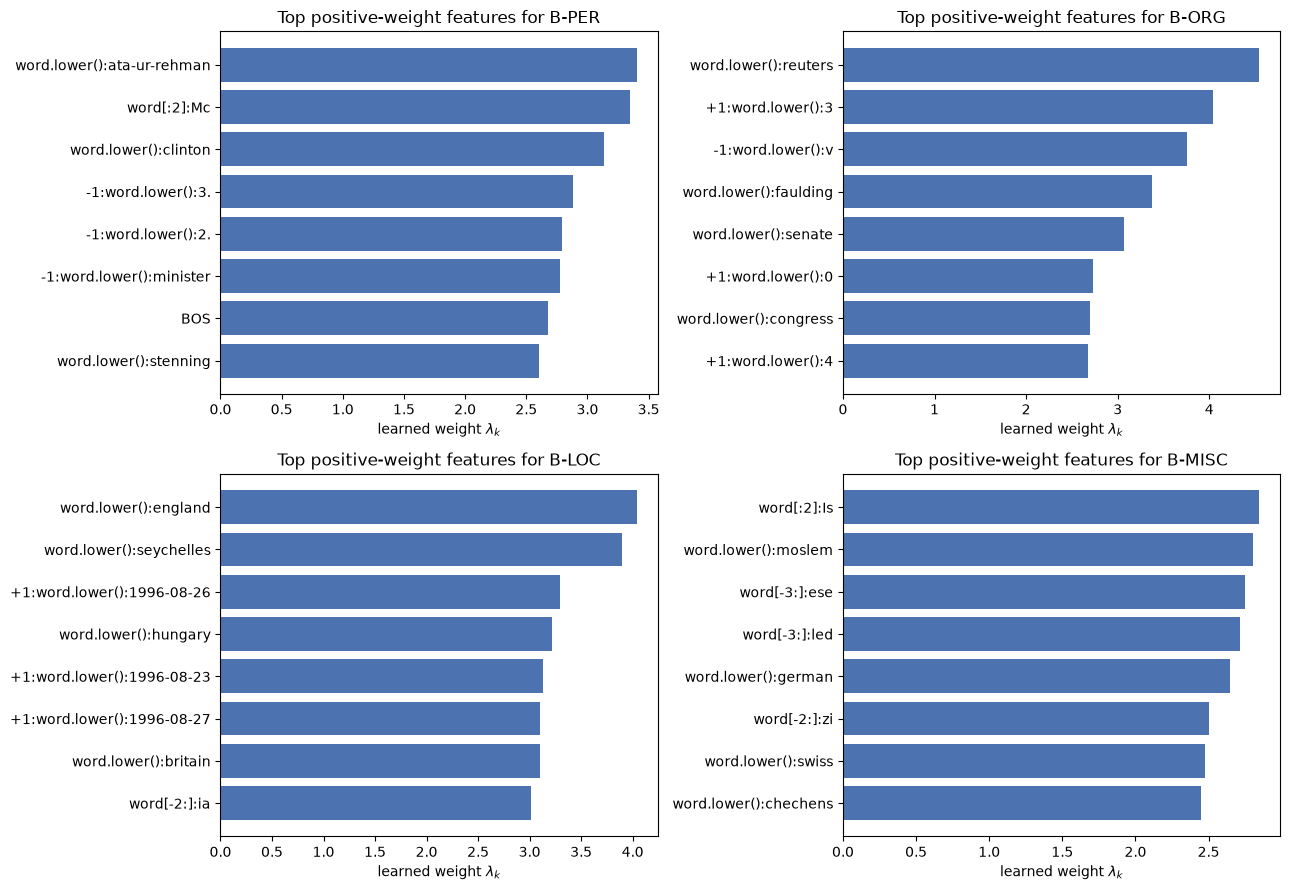

In [11]:

from collections import defaultdict

# crf.state_features_ maps (feature_name, tag) -> weight
by_tag = defaultdict(list)
for (feat_name, tag), weight in crf.state_features_.items():
    by_tag[tag].append((feat_name, weight))

entity_start_tags = ["B-PER", "B-ORG", "B-LOC", "B-MISC"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()

for ax, tag in zip(axes, entity_start_tags):
    top = sorted(by_tag[tag], key=lambda kv: kv[1], reverse=True)[:8]
    names = [n for n, _ in top][::-1]
    weights = [w for _, w in top][::-1]
    ax.barh(names, weights, color="#4C72B0")
    ax.set_title(f"Top positive-weight features for {tag}")
    ax.set_xlabel(r"learned weight $\lambda_k$")

plt.tight_layout()
plt.savefig("top_features_per_entity.png", dpi=110)
plt.show()



Capitalization- and title-case-related features (`word.istitle()`,
neighboring-word title case, POS tag `NNP`/`NNPS` for proper nouns) should
dominate the top of `B-PER`, `B-ORG`, and `B-LOC` — exactly matching the
intuition that named entities in English news text are almost always
capitalized. This is the model *showing its work*: we can literally read
off which hand-crafted signals it decided were most diagnostic, something
a black-box neural tagger doesn't give you nearly as directly.

### 5.7 F1 per entity type, visualized


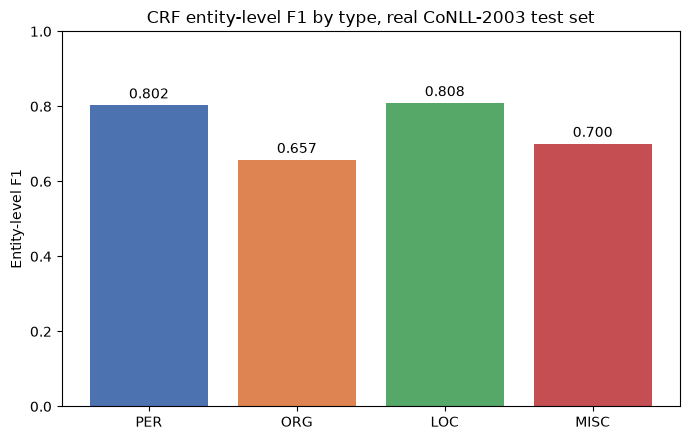

In [12]:

ent_order = ["PER", "ORG", "LOC", "MISC"]
f1s = [entity_scores[et]["f1"] for et in ent_order]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(ent_order, f1s, color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
for bar, f1 in zip(bars, f1s):
    ax.text(bar.get_x() + bar.get_width() / 2, f1 + 0.01, f"{f1:.3f}",
             ha="center", va="bottom", fontsize=10)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Entity-level F1")
ax.set_title("CRF entity-level F1 by type, real CoNLL-2003 test set")
plt.tight_layout()
plt.savefig("f1_per_entity.png", dpi=110)
plt.show()



### 5.8 Example predictions: predicted vs. true, side by side

Real sentences from the test set, with the model's predicted BIO tags
against the ground truth, so we can see concretely where the model agrees
and where it doesn't.


In [13]:

def show_prediction(idx):
    tokens = test_split[idx]["tokens"]
    true_tags = [label_names[t] for t in test_split[idx]["ner_tags"]]
    pred_tags = crf.predict([sentence_to_features(tokens)])[0]

    print("TOKEN".ljust(15), "TRUE".ljust(10), "PRED".ljust(10), "")
    print("-" * 40)
    for tok, true_t, pred_t in zip(tokens, true_tags, pred_tags):
        marker = "" if true_t == pred_t else "  <-- MISMATCH"
        print(tok.ljust(15), true_t.ljust(10), pred_t.ljust(10), marker)
    print()

for idx in [1, 15, 42]:
    print(f"=== Test sentence #{idx} ===")
    show_prediction(idx)


=== Test sentence #1 ===
TOKEN           TRUE       PRED       
----------------------------------------
Nadim           B-PER      B-PER      
Ladki           I-PER      I-PER      

=== Test sentence #15 ===
TOKEN           TRUE       PRED       
----------------------------------------
Bitar           B-PER      B-PER      
pulled          O          O          
off             O          O          
fine            O          O          
saves           O          O          
whenever        O          O          
they            O          O          
did             O          O          
.               O          O          

=== Test sentence #42 ===
TOKEN           TRUE       PRED       
----------------------------------------
Japan           B-LOC      B-LOC      
then            O          O          
laid            O          O          
siege           O          O          
to              O          O          
the             O          O          
Syrian          B-


## 6. Use cases

CRF-based (and, later, neural) NER underlies a lot of real information
pipelines:

- **Information extraction pipelines** — turning free text (news, reports,
  contracts) into structured records: "who did what, where, for which
  organization" — the direct application demonstrated above.
- **Resume parsing** — applicant tracking systems extract candidate names,
  companies, schools, and skills from unstructured resume text as a
  sequence-labeling problem structurally identical to what we just built.
- **Biomedical entity recognition** — extracting gene names, drug names,
  and disease mentions from clinical notes and biomedical literature
  (e.g. the BioCreative and NCBI-Disease shared tasks use CRF and
  CRF-adjacent models as strong baselines) to power drug-interaction and
  literature-mining systems.
- **Search query understanding** — recognizing that "flights to boston
  tomorrow" contains a `LOC` and a `DATE` lets a search engine route the
  query to the right structured backend instead of treating it as a bag
  of keywords.

## 7. Limitations & debates

**Hand-crafted features are labor-intensive and don't transfer.** Every
feature in §5.2 — capitalization, suffixes, POS tags, the neighboring-word
window — was chosen by hand based on knowledge of English news text. A
feature set tuned this way can perform noticeably worse on a different
domain (biomedical text, where entity names don't follow English
capitalization conventions and use highly technical vocabulary; social
media text, which is full of noisy capitalization, abbreviations, and
non-standard spelling) or a different language (many languages don't mark
proper nouns with capitalization at all, e.g. Arabic, or use capitalization
completely differently, e.g. German, which capitalizes all nouns). Every
time you move domains you're back to hand-designing features again. **This
is the concrete, practical motivation for the shift to neural sequence
taggers** — BiLSTM-CRF architectures (Lample et al., 2016) and later
fine-tuned transformer models (BERT-NER, covered in this domain's
bert-fine-tuning tutorial) that learn their own feature representations
from raw text instead of requiring them by hand. The CRF *layer* often
survives on top of these neural encoders (a BiLSTM-CRF is still a CRF —
just with the state/transition scores computed by a neural network instead
of hand-crafted feature functions), which is a good sign that the CRF
formalism from §3 wasn't wasted effort even once features stop being
hand-designed.

**Exact/beam inference over tag sequences is still a real computational
cost.** Finding the highest-scoring $\mathbf{y}$ (or decoding top
candidates) requires a Viterbi-style dynamic program over the tag lattice,
same as an HMM. Neural sequence taggers that emit a CRF layer on top still
pay this same decoding cost; taggers that instead decode tag-by-tag
greedily (or with a small beam) trade away joint-sequence exactness for
speed — a real, ongoing tradeoff in production NER systems, not something
neural architectures make free.

**Entity boundary disagreements are a genuine, unresolved annotation
problem.** Should "New York City" be tagged as one `LOC` entity, or should
"New York" and "City" be split? Should "Bank of America" be one `ORG`, or
does "Bank" alone ever count separately? Human annotators genuinely
disagree on cases like these, and CoNLL-2003's own guidelines had to make
somewhat arbitrary calls to keep annotation consistent. Because the
*ceiling* on achievable F1 is bounded by how consistently humans can even
agree on the correct answer, no NER model — CRF or neural — can be
expected to reach 100% F1 on real benchmarks, and improvements past the
inter-annotator-agreement ceiling stop being meaningful signal about model
quality and start being noise in the test set's own labels.

**Class imbalance inflates naive accuracy.** The overwhelming majority of
tokens in any sentence are tagged `O` (§5.4) — a model that predicted `O`
for everything would already score high on raw token accuracy. This is
exactly why we reported per-entity precision/recall/F1 (excluding `O` from
the summary) rather than leading with overall accuracy.



## 8. References

- Lafferty, J., McCallum, A., Pereira, F. (2001). *Conditional Random
  Fields: Probabilistic Models for Segmenting and Labeling Sequence
  Data.* Proceedings of ICML 2001. (Origin of CRFs.)
- Sang, E.F.T.K. & De Meulder, F. (2003). *Introduction to the CoNLL-2003
  Shared Task: Language-Independent Named Entity Recognition.*
  Proceedings of CoNLL-2003. (Source of the dataset used in this
  tutorial.)
- Ramshaw, L.A. & Marcus, M.P. (1995). *Text Chunking Using
  Transformation-Based Learning.* Proceedings of the Third ACL Workshop
  on Very Large Corpora. (Origin of the BIO/IOB tagging scheme.)
- Lample, G., Ballesteros, M., Subramanian, S., Kawakami, K., Dyer, C.
  (2016). *Neural Architectures for Named Entity Recognition.*
  Proceedings of NAACL-HLT 2016. (The BiLSTM-CRF neural successor
  discussed in §7.)
- Jurafsky, D. & Martin, J.H. *Speech and Language Processing*, Chapters
  8 (Sequence Labeling for Parts of Speech and Named Entities) and 17.
- `sklearn-crfsuite` documentation:
  https://sklearn-crfsuite.readthedocs.io/
